In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib.patches import Patch

In [98]:
df = pd.read_csv("Spotify_Dataset_V3.csv", delimiter=';')
df_us = df[df['Nationality'] == 'United States'].copy()

print(f"Total rows (US): {len(df_us):,}")
print(f"Columns: {list(df_us.columns)}")
print(f"\nNull values present: {df_us.isna().values.any()}")
df_us.head(3)

Total rows (US): 274,804
Columns: ['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL']

Null values present: False


,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL
8,6,Flowers,Miley Cyrus,29/05/2023,0.707,0.681,-4325.0,0.067,0.063,0.000,0.646,Artist 1,Miley Cyrus,Nationality 1,United States,Anglo-America,195,195.0,4DHcnVTT87F0zZhRPYmZ3B,https://open.spotify.com/track/4DHcnVTT87F0zZh...
9,7,Daylight,David Kushner,29/05/2023,0.508,0.430,-9475.0,0.034,0.830,0.000,0.324,Artist 1,David Kushner,Nationality 1,United States,Anglo-America,194,194.0,1odExI7RdWc4BT515LTAwj,https://open.spotify.com/track/1odExI7RdWc4BT5...
10,8,Kill Bill,SZA,29/05/2023,0.644,0.735,-5747.0,0.039,0.052,0.144,0.418,Artist 1,SZA,Nationality 1,United States,Anglo-America,193,193.0,1Qrg8KqiBpW07V7PNxwwwL,https://open.spotify.com/track/1Qrg8KqiBpW07V7...


In [99]:
AUDIO_FEATURES = ['Danceability', 'Energy', 'Instrumentalness']

df_us = df_us.dropna(subset=['Artists'] + AUDIO_FEATURES)
print(f"Rows after dropping nulls: {len(df_us):,}")

Rows after dropping nulls: 274,804


In [100]:
G = nx.Graph()
for artists in df_us['Artists'].dropna():
    artist_list = [a.strip() for a in artists.split(',')]
    for i in range(len(artist_list)):
        for j in range(i+1, len(artist_list)):
            G.add_edge(artist_list[i], artist_list[j])

In [101]:
degree      = nx.degree_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=500)
betweenness = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    'artist':                 list(degree.keys()),
    'degree_centrality':      list(degree.values()),
    'betweenness_centrality': list(betweenness.values()),
    'eigenvector_centrality': list(eigenvector.values()),
})

print("Top 10 by eigenvector centrality:")
centrality_df.sort_values('eigenvector_centrality', ascending=False).head(10)

Top 10 by eigenvector centrality:


,artist,degree_centrality,betweenness_centrality,eigenvector_centrality
38,Travis Scott,0.037175,0.030363,0.285032
122,Drake,0.029740,0.018700,0.247827
119,DJ Khaled,0.032218,0.023297,0.243258
47,Future,0.037175,0.056306,0.235685
4,21 Savage,0.027261,0.015851,0.215917
39,Young Thug,0.034696,0.032678,0.188574
98,Quavo,0.024783,0.020281,0.181327
2,Metro Boomin,0.021066,0.004982,0.178377
118,Kanye West,0.034696,0.054929,0.175045
390,Ty Dolla $ign,0.028501,0.028209,0.171446


In [102]:
df_exploded = df_us.copy()
df_exploded['artist_single'] = df_exploded['Artists'].str.split(',')
df_exploded = df_exploded.explode('artist_single')
df_exploded['artist_single'] = df_exploded['artist_single'].str.strip()

artist_features = (
    df_exploded
    .groupby('artist_single')[AUDIO_FEATURES]
    .mean()
    .reset_index()
    .rename(columns={'artist_single': 'artist'})
)

# Merge centrality scores
artist_features = artist_features.merge(centrality_df, on='artist', how='left')
artist_features[['degree_centrality','betweenness_centrality','eigenvector_centrality']] = (
    artist_features[['degree_centrality','betweenness_centrality','eigenvector_centrality']].fillna(0)
)

print(f"Unique artists with feature profiles: {len(artist_features):,}")
artist_features.head()

Unique artists with feature profiles: 1,094


,artist,Danceability,Energy,Instrumentalness,degree_centrality,betweenness_centrality,eigenvector_centrality
0,,0.722000,0.790000,0.000000,0.001239,0.000000,2.798952e-19
1,$NOT,0.678097,0.721516,0.000075,0.002478,0.001974,8.357919e-03
2,$uicideboy$,0.792000,0.511000,0.000000,0.000000,0.000000,0.000000e+00
3,(G)I-DLE,0.627700,0.796433,0.000000,0.009913,0.000057,4.372723e-04
4,*NSYNC,0.645483,0.939621,0.000000,0.000000,0.000000,0.000000e+00


In [103]:
scaler = StandardScaler()
X = scaler.fit_transform(artist_features[AUDIO_FEATURES])

print(f"Feature matrix shape: {X.shape}")
print("Mean per feature after scaling (should be ~0):", X.mean(axis=0).round(4))
print("Std  per feature after scaling (should be ~1):", X.std(axis=0).round(4))

Feature matrix shape: (1094, 3)
Mean per feature after scaling (should be ~0): [-0. -0.  0.]
Std  per feature after scaling (should be ~1): [1. 1. 1.]


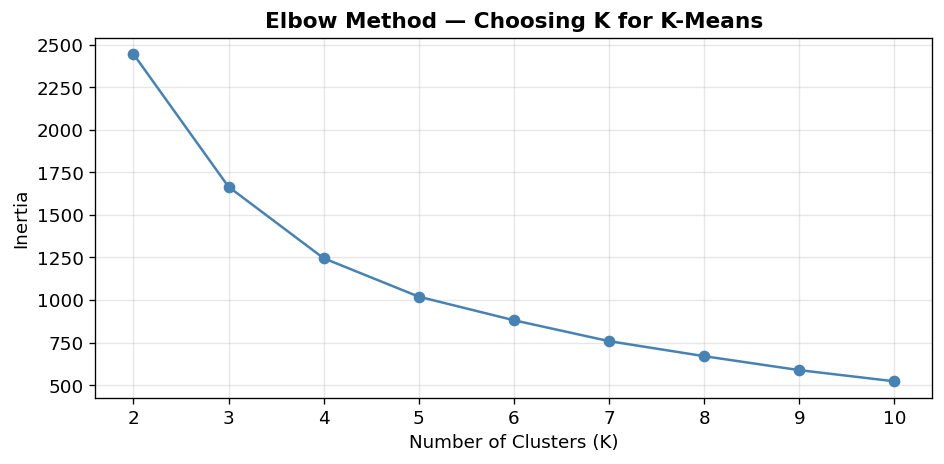

In [104]:
inertia_values = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertia_values.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(list(K_range), inertia_values, 'o-', color='steelblue')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Choosing K for K-Means', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('choosing_k.png', bbox_inches='tight')
plt.show()

In [105]:
K = 4

km_final = KMeans(n_clusters=K, n_init=10, random_state=42)
artist_features['cluster'] = km_final.fit_predict(X)

print(f"K-Means applied with K = {K}")
print("\nArtists per cluster:")
print(artist_features['cluster'].value_counts().sort_index())

K-Means applied with K = 4

Artists per cluster:
cluster
0    365
1    494
2     14
3    221
Name: count, dtype: int64


In [106]:
cluster_profiles = (
    artist_features
    .groupby('cluster')[AUDIO_FEATURES]
    .mean()
    .round(4)
)

print("=== Cluster Audio Feature Profiles ===")
print(cluster_profiles)
print()

# Auto-label each cluster based on feature values
for c, row in cluster_profiles.iterrows():
    tags = []
    if row['Danceability'] > 0.7:
        tags.append('High Danceability')
    elif row['Danceability'] < 0.5:
        tags.append('Low Danceability')
    else:
        tags.append('Moderate Danceability')
    if row['Energy'] > 0.8:
        tags.append('High Energy')
    elif row['Energy'] < 0.4:
        tags.append('Low Energy')
    else:
        tags.append('Moderate Energy')
    if row['Instrumentalness'] > 0.1:
        tags.append('Instrumental')
    else:
        tags.append('Vocal-heavy')
    print(f"  Cluster {c}: {', '.join(tags)}")

=== Cluster Audio Feature Profiles ===
         Danceability  Energy  Instrumentalness
cluster                                        
0              0.7811  0.5551            0.0034
1              0.6714  0.7773            0.0092
2              0.4446  0.4889            0.5166
3              0.4975  0.4704            0.0050

  Cluster 0: High Danceability, Moderate Energy, Vocal-heavy
  Cluster 1: Moderate Danceability, Moderate Energy, Vocal-heavy
  Cluster 2: Low Danceability, Moderate Energy, Instrumental
  Cluster 3: Low Danceability, Moderate Energy, Vocal-heavy


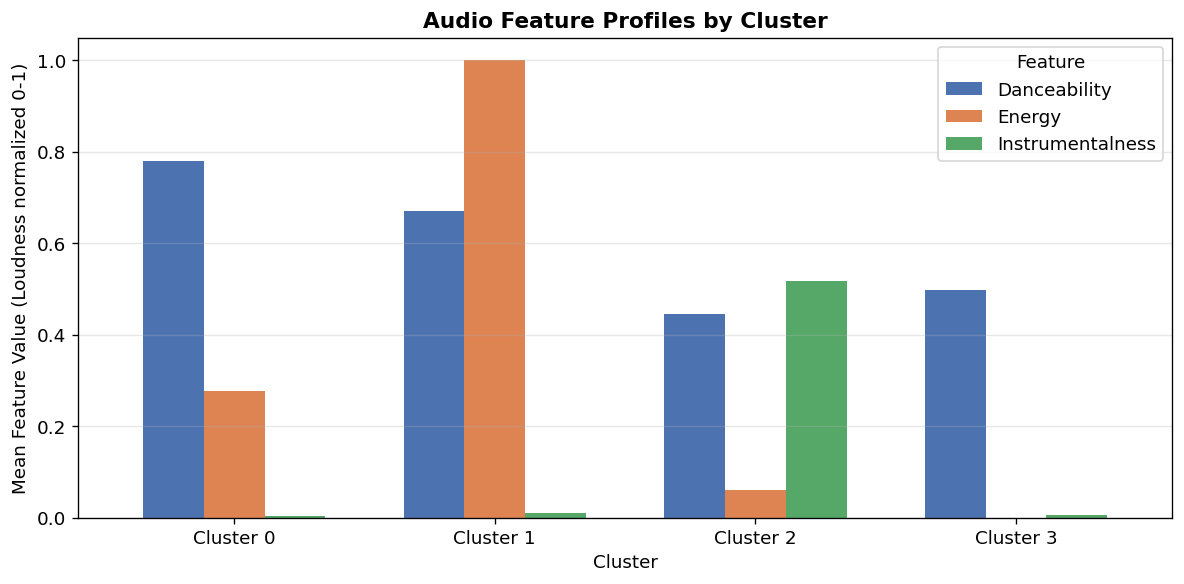

In [107]:
cluster_profiles_viz = cluster_profiles.copy()
loud_min = cluster_profiles_viz['Energy'].min()
loud_max = cluster_profiles_viz['Energy'].max()
cluster_profiles_viz['Energy'] = (
    (cluster_profiles_viz['Energy'] - loud_min) / (loud_max - loud_min)
)

ax = cluster_profiles_viz.plot(
    kind='bar', figsize=(10, 5), width=0.7,
    color=['#4C72B0', '#DD8452', '#55A868']
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean Feature Value (Loudness normalized 0-1)')
ax.set_title('Audio Feature Profiles by Cluster', fontsize=13, fontweight='bold')
ax.set_xticklabels([f'Cluster {i}' for i in range(K)], rotation=0)
ax.legend(title='Feature')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight')
plt.show()

In [108]:
for c in range(K):
    top = (
        artist_features[artist_features['cluster'] == c]
        .sort_values('degree_centrality', ascending=False)
        .head(10)[['artist', 'Danceability', 'Energy',
                   'Instrumentalness', 'degree_centrality']]
    )
    print(f"\n{'='*55}")
    print(f"  CLUSTER {c}  —  Top 10 artists by degree centrality")
    print(f"{'='*55}")
    print(top.to_string(index=False))


  CLUSTER 0  —  Top 10 artists by degree centrality
       artist  Danceability   Energy  Instrumentalness  degree_centrality
 Travis Scott      0.765681 0.617255          0.000063           0.037175
       Future      0.691611 0.581648          0.007427           0.037175
      Becky G      0.801465 0.707003          0.000762           0.035936
   Young Thug      0.783677 0.565067          0.000604           0.034696
   Kanye West      0.677447 0.584855          0.005687           0.034696
        Drake      0.808078 0.504215          0.003660           0.029740
Ty Dolla $ign      0.730091 0.579676          0.000409           0.028501
    21 Savage      0.751592 0.527201          0.029145           0.027261
  Nicki Minaj      0.807067 0.660170          0.000025           0.026022
     Lil Baby      0.842451 0.563035          0.000000           0.024783

  CLUSTER 1  —  Top 10 artists by degree centrality
           artist  Danceability   Energy  Instrumentalness  degree_centrality
  

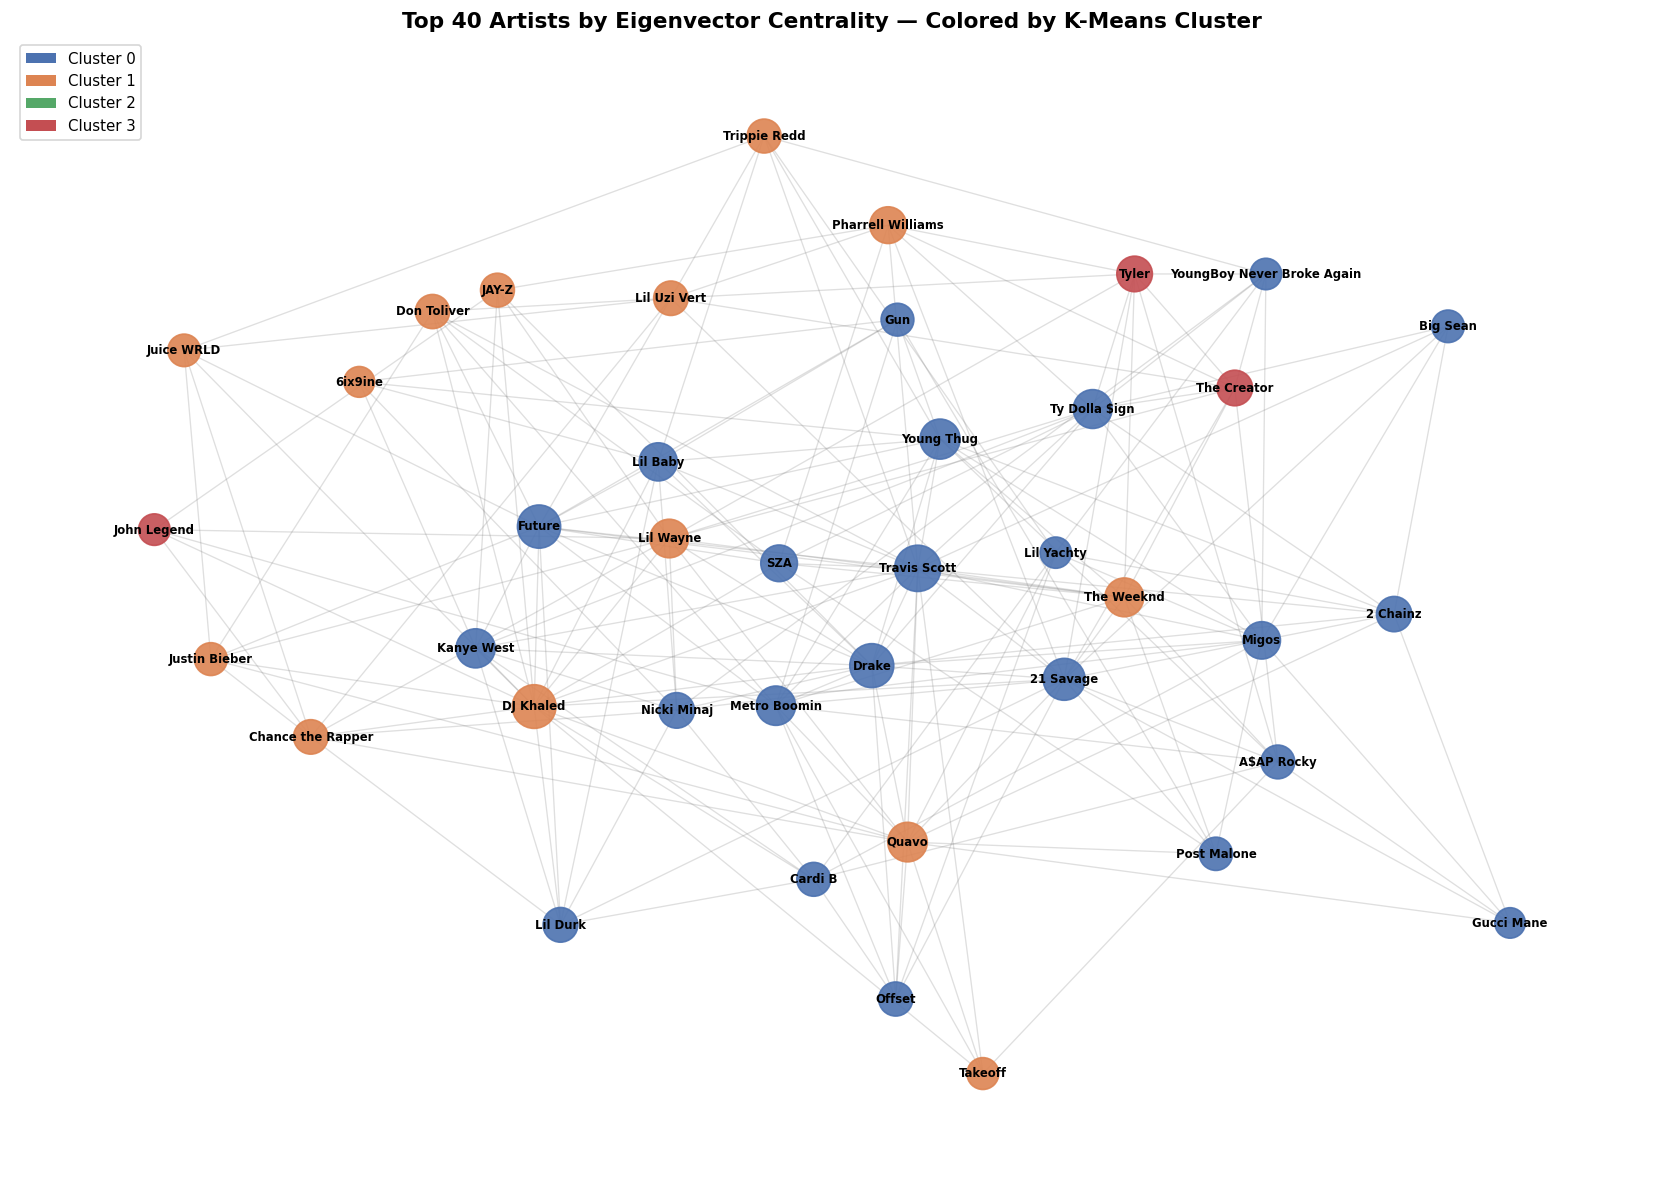

In [109]:
palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

cluster_lookup = dict(zip(artist_features['artist'], artist_features['cluster']))

# Top 40 artists by eigenvector centrality
top_nodes = sorted(eigenvector, key=eigenvector.get, reverse=True)[:40]
subgraph  = G.subgraph(top_nodes)

node_colors = [
    palette[cluster_lookup.get(node, 0) % len(palette)]
    for node in subgraph.nodes()
]
node_sizes = [
    2000 * eigenvector.get(node, 0.01) + 200
    for node in subgraph.nodes()
]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=0.8, seed=42)

nx.draw_networkx_edges(subgraph, pos, alpha=0.25, edge_color='gray', width=0.8)
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(subgraph, pos, font_size=7, font_weight='bold')

legend_elements = [
    Patch(facecolor=palette[i], label=f'Cluster {i}') for i in range(K)
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.title('Top 40 Artists by Eigenvector Centrality — Colored by K-Means Cluster',
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('network_with_clusters.png', bbox_inches='tight')
plt.show()

In [110]:
bridge_artists = (
    artist_features
    .sort_values('betweenness_centrality', ascending=False)
    .head(15)[['artist','cluster','Danceability','Energy',
               'Instrumentalness','betweenness_centrality','degree_centrality']]
)

print("=== Top 15 Bridge Artists (by betweenness centrality) ===")
print(bridge_artists.to_string(index=False))

=== Top 15 Bridge Artists (by betweenness centrality) ===
           artist  cluster  Danceability   Energy  Instrumentalness  betweenness_centrality  degree_centrality
          Becky G        0      0.801465 0.707003          0.000762                0.081808           0.035936
           Future        0      0.691611 0.581648          0.007427                0.056306           0.037175
       Kanye West        0      0.677447 0.584855          0.005687                0.054929           0.034696
      Nicki Minaj        0      0.807067 0.660170          0.000025                0.049871           0.026022
     Trippie Redd        1      0.699193 0.667690          0.000121                0.045035           0.034696
         J Balvin        1      0.733310 0.697035          0.000158                0.044490           0.023544
     David Guetta        1      0.640524 0.831176          0.000000                0.041455           0.019827
            Diplo        1      0.664778 0.726555     

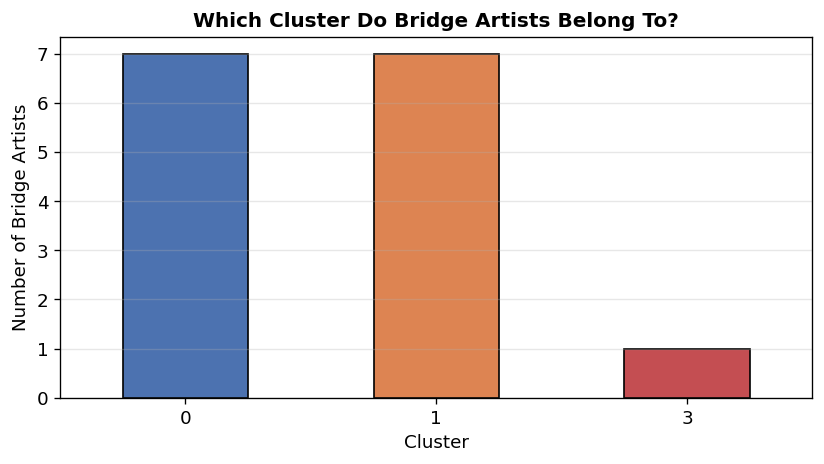

In [111]:
bridge_cluster_dist = bridge_artists['cluster'].value_counts().sort_index()

bridge_cluster_dist.plot(
    kind='bar',
    color=[palette[i % len(palette)] for i in bridge_cluster_dist.index],
    figsize=(7, 4), edgecolor='black'
)
plt.xlabel('Cluster')
plt.ylabel('Number of Bridge Artists')
plt.title('Which Cluster Do Bridge Artists Belong To?', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bridge_artist_clusters.png', bbox_inches='tight')
plt.show()